In [1]:
# Import necessary libraries for data manipulation and analysis
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
from datetime import datetime, timedelta # Date operations

#Import necessary libraries for transformations
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
from scipy.stats import skew, kurtosis

# Import libraries for plotting and visualization
import matplotlib.pyplot as plt # Matplotlib for basic plotting
import seaborn as sns # Seaborn for enhanced visualization
import plotly.express as px # Plotly for interactive plots

# Import libraries for time series analysis and modeling
from statsmodels.tsa.stattools import adfuller # Augmented Dickey-Fuller Test for stationarity check
from statsmodels.tsa.stattools import kpss # Kwiatkowski-Phillips-Schmidt-Shin Test for stationarity check
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMAX model for time series forecasting
from statsmodels.tsa.seasonal import seasonal_decompose # Seasonal decomposition for trend, seasonal, and residual components
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima #SARIMAX using pmdarima

# Import necessary libraries for computing acf and pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # For autocorrelation and partial autocorrelation plots
from statsmodels.tsa.stattools import acf, pacf  # For computing autocorrelation and partial autocorrelation

#Import libraries for multicollineaarity
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Import libraries for transformations
import joblib



In [2]:
from SARIMAX import remove_multicollinear, calculate_vif
import datascript
from datascript import load_data, split_data
import os

SARIMAX for VISAYAS
DATA PREPROCESSING

In [3]:
#Import the necessary files
base_path = os.path.dirname(os.path.abspath(datascript.__file__))  # Gets the current working directory
complete_vis_gwap = load_data("VIS",'GWAP', features = False, transformed=False)
complete_vis_lwap = load_data("VIS",'LWAP', features = False, transformed=False)

In [4]:
GWAP = load_data("VIS",'GWAP', model='SARIMAX', features = False, transformed=True)
LWAP = load_data("VIS",'LWAP', model='SARIMAX', features = False, transformed=True)

GWAP_transformed_features = load_data("VIS",'GWAP', model='SARIMAX', features = True, transformed=True)

In [5]:
%run SARIMAX.py
#Prepare exogenous variables and check for multicollinearity
full_transformed_exog = GWAP_transformed_features.drop(columns=['GWAP'])
full_transformed_exog = full_transformed_exog.shift(1)
full_transformed_exog = full_transformed_exog.fillna(0)
full_exog_train, full_exog_test = split_data(full_transformed_exog, False)

exog_train = remove_multicollinear(full_exog_train, 10)
calculate_vif(exog_train)

final_exog = drop_unmatched_columns(full_transformed_exog, exog_train)

Dropping TMIN_Catbalogan with VIF of 51.36792312526932
Dropping TMAX_Catarman with VIF of 43.64626790595232
Dropping TMAX_Maasin with VIF of 40.98755993281044
Dropping TMAX_Roxas City with VIF of 31.438791077614287
Dropping TMAX_Dumaguete with VIF of 26.06539143097628
Dropping TMIN_Maasin with VIF of 24.55396424299972
Dropping TMIN_Roxas City with VIF of 18.840498323182718
Dropping TMIN_Catarman with VIF of 14.460175876248812
Dropping Demand with VIF of 12.585017194241601
Final VIF values:
                 feature       VIF
0              FLOW_VIS  7.244426
1       Reserve_GWAP_Fr  5.948152
2       Reserve_GWAP_Ru  3.869119
3       Reserve_GWAP_Rd  1.700528
4       Reserve_GWAP_Dr  7.370311
5   RAINFALL_Catbalogan  3.576478
6       TMAX_Catbalogan  7.826372
7   RAINFALL_Roxas City  2.047123
8     RAINFALL_Catarman  3.351565
9       RAINFALL_Maasin  2.630707
10   RAINFALL_Dumaguete  2.239345
11       TMIN_Dumaguete  9.039636


In [6]:
#Prepare the necessary datasets
#Target Variables
GWAP_train, GWAP_test = split_data(GWAP, False)
LWAP_train, LWAP_test = split_data(LWAP, False)

#Untransformed variables for verification 
untransformed_GWAP_train, untransformed_GWAP_test = split_data(complete_vis_gwap, False)
untransformed_LWAP_train, untransformed_LWAP_test = split_data(complete_vis_lwap, False)



/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()
/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



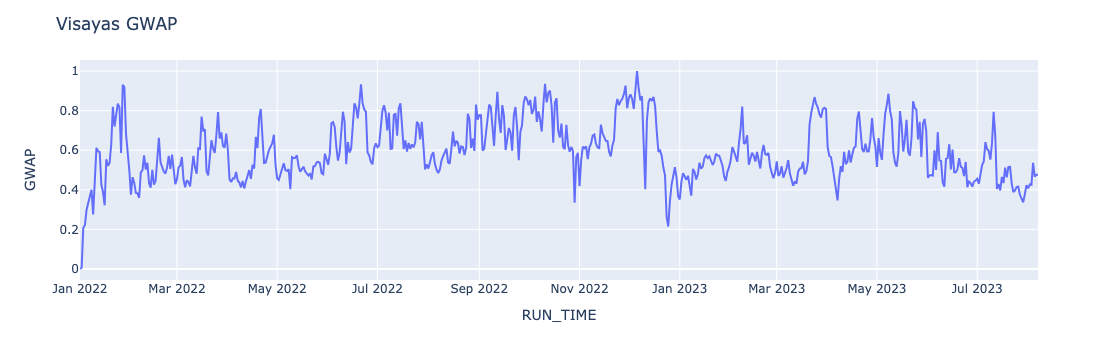

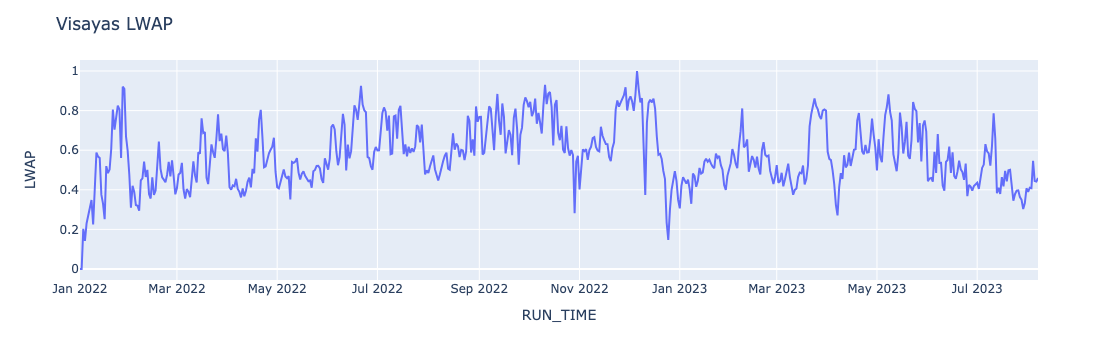

In [7]:
#Plotting Train LWAP ang GWAP
# Create the line plot
gwap_plot = px.line(GWAP_train, x=GWAP_train.index, y='GWAP')
lwap_plot = px.line(LWAP_train, x=LWAP_train.index, y='LWAP')
# Set the title using the ticker value
gwap_plot.update_layout(title=f"Visayas GWAP")
lwap_plot.update_layout(title=f"Visayas LWAP")
# Display the plot
gwap_plot.show()
lwap_plot.show()

Differencing

In [8]:
%run SARIMAX.py

#Checking for stationarity in GWAP data
differenced_GWAP = perform_differencing(GWAP_train, GWAP)
differenced_LWAP = perform_differencing(LWAP_train, LWAP)

GWAP_train, GWAP_test = split_data(differenced_GWAP, False)
LWAP_train, LWAP_test = split_data(differenced_LWAP, False)

Data is stationary after differencing 0 times.
Data is stationary after differencing 0 times.


In [9]:
#Perform differencing on train exogenous data
diff_full_exog = perform_df_differencing(exog_train, final_exog)
diff_full_exog = diff_full_exog.fillna(0)
exog_train, exog_test = split_data(diff_full_exog, False)

/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Column 'FLOW_VIS' is stationary after differencing 0 times.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Column 'Reserve_GWAP_Fr' is stationary after differencing 1 times.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




...

/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Column 'RAINFALL_Catarman' is stationary after differencing 0 times.
Column 'RAINFALL_Maasin' is stationary after differencing 0 times.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Column 'RAINFALL_Dumaguete' is stationary after differencing 0 times.
Column 'TMIN_Dumaguete' is stationary after differencing 0 times.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Order Specification

The ACF for GWAP is seen below
The PACF for GWAP is seen below


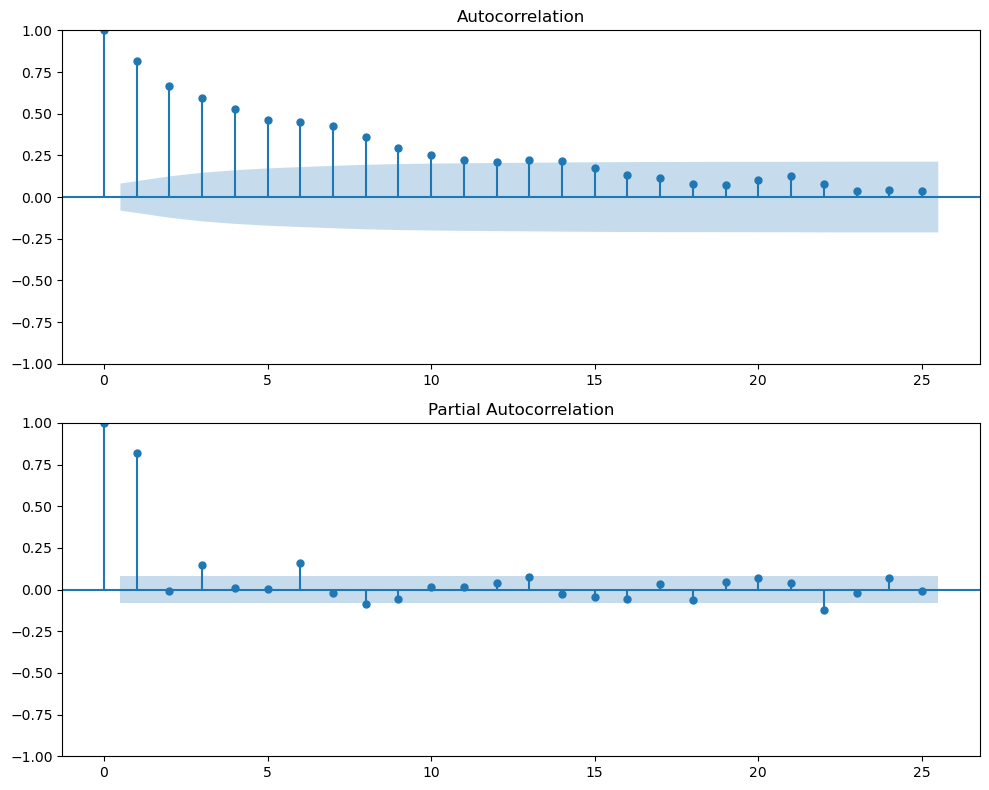

The ACF for LWAP is seen below
The PACF for LWAP is seen below


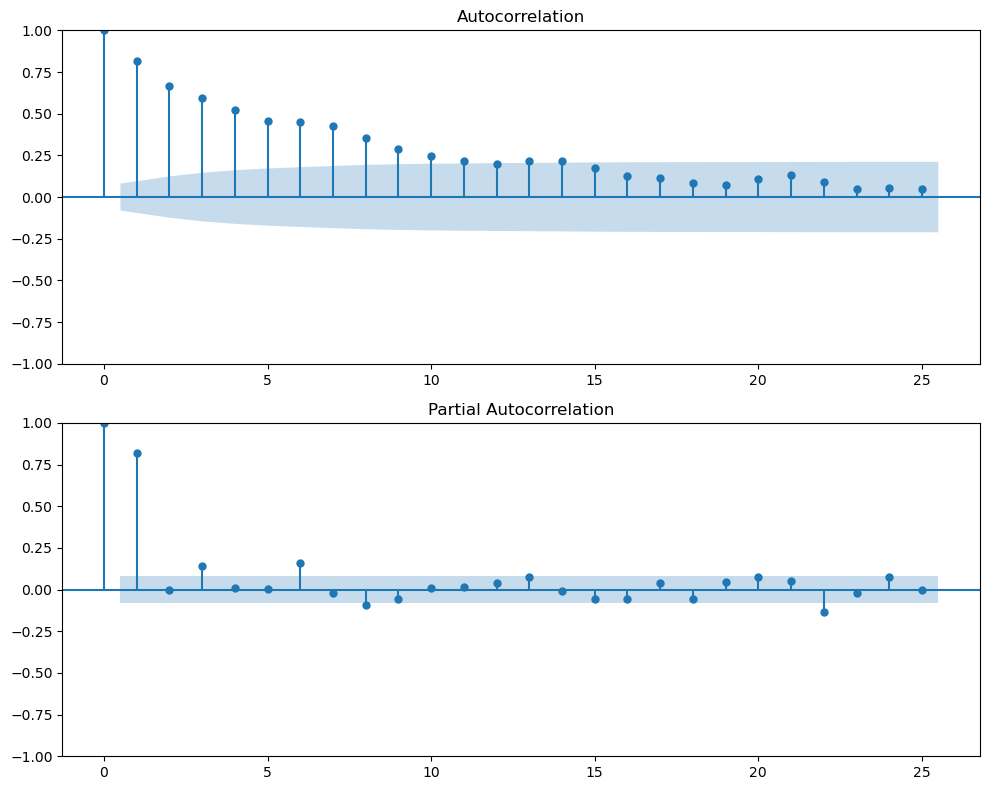

In [10]:
%run SARIMAX.py
plot_orders(GWAP_train, lags=25, alpha=0.05, var='GWAP')
plot_orders(LWAP_train, lags=25, alpha=0.05, var='LWAP')

GWAP and LWAP Forecasting

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
GWAP_sarimax = seasonal_auto_arima(GWAP_train, max_p=1, max_d=2, max_q=13, exog_data=exog_train )

#Display results of previous function
GWAP_sarimax

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
LWAP_sarimax = seasonal_auto_arima(LWAP_train, max_p=1, max_d=2, max_q=14, exog_data=exog_train )

#Display results of previous function
LWAP_sarimax

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -1.129346
         Iterations: 12
         Function evaluations: 1933
                                      SARIMAX Results                                      
Dep. Variable:                                GWAP   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 14)   Log Likelihood                 659.538
Date:                             Sat, 15 Mar 2025   AIC                          -1285.076
Time:                                     16:43:41   BIC                          -1210.817
Sample:                                 01-01-2022   HQIC                         -1256.132
                                      - 08-07-2023                                         
Covariance Type:                               opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -1.057690
         Iterations: 11
         Function evaluations: 1782
                                      SARIMAX Results                                      
Dep. Variable:                                LWAP   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 14)   Log Likelihood                 617.691
Date:                             Sat, 15 Mar 2025   AIC                          -1201.382
Time:                                     16:46:05   BIC                          -1127.122
Sample:                                 01-01-2022   HQIC                         -1172.437
                                      - 08-07-2023                                         
Covariance Type:                               opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

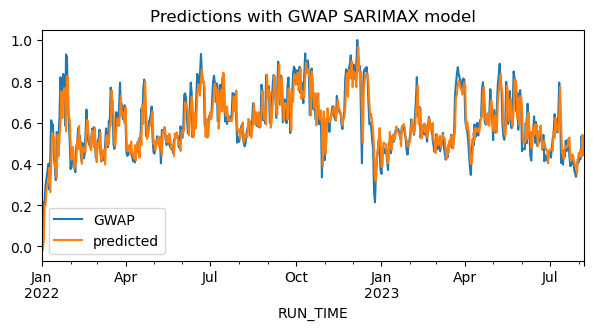

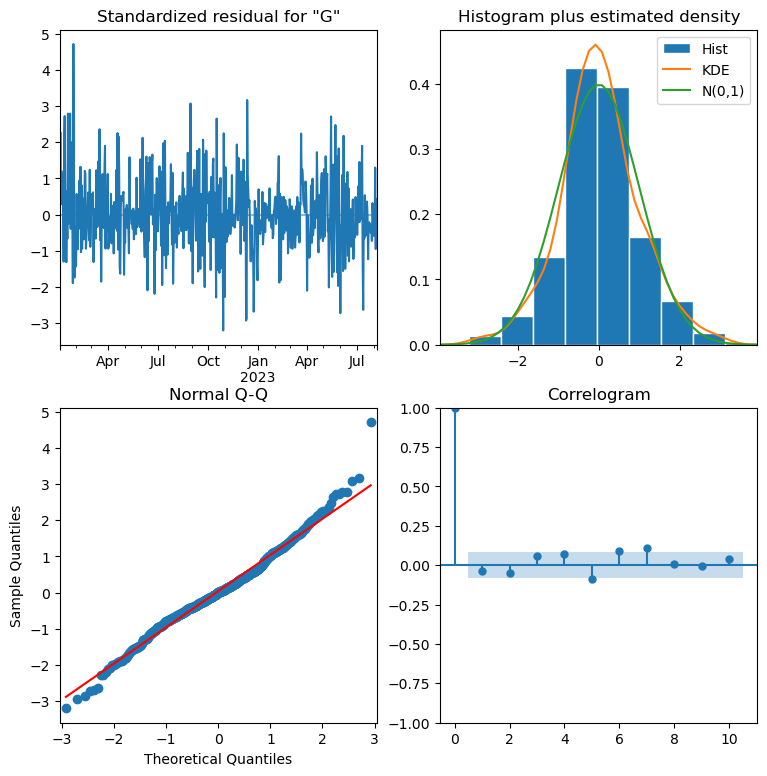

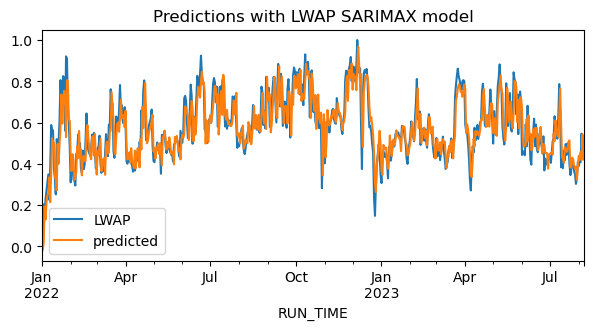

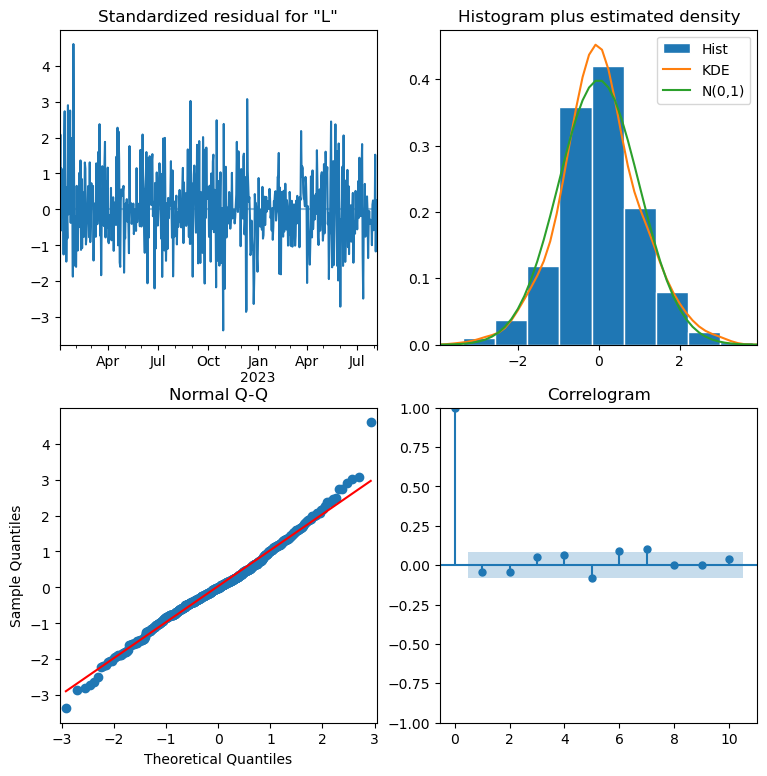

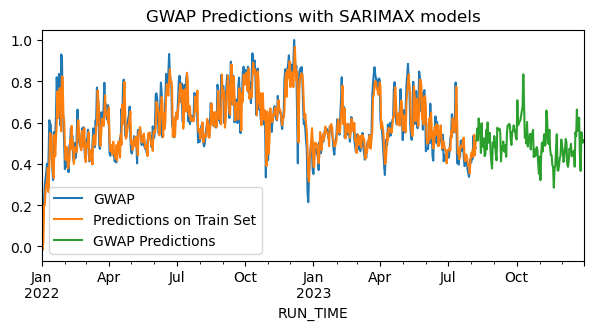

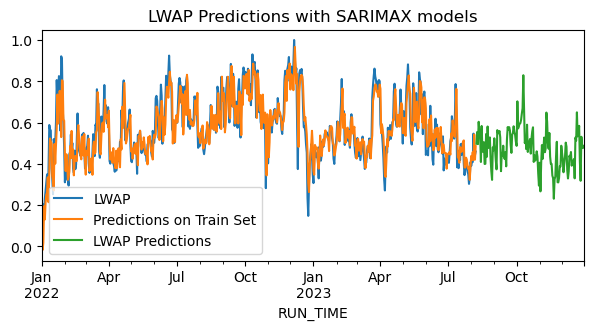

In [11]:
#Optimized orders for GWAP are (1,1,1)(2,0,0,14) and for LWAP are (1,1,1)(2,0,0)(14)
#This function fits the model and plots predictions on the train set; shows the summary of results and residuals diagnostics; and predicts on train set
%run SARIMAX.py

gwap_model_results, lwap_model_results, gwap_test_predict, lwap_test_predict, gwap_train_predict, lwap_train_predict = fit_SARIMAX(gwap_endog=GWAP_train, lwap_endog= LWAP_train, train_exog=exog_train, gwap_order=(1,1,1), gwap_seasonal_order=(2,0,0,14), lwap_order = (1,1,1), lwap_seasonal_order=(2,0,0,14), GWAP_test=GWAP_test, LWAP_test=LWAP_test, exog_test = exog_test)


GWAP Residual Analysis

In [12]:
#Generate residuals for GWAP
%run GARCH.py

gwap_resid_complete, gwap_resid_train = generate_resid(
    'GWAP',
    GWAP_train,
    GWAP_test,
    gwap_train_predict,
    gwap_test_predict,
    gwap_model_results
)

2022-01-01    0.000000
2022-01-02    0.022973
2022-01-03    0.186783
2022-01-04    0.023475
2022-01-05    0.098033
2022-01-06    0.053981
2022-01-07    0.062649
2022-01-08    0.082926
2022-01-09   -0.105093
2022-01-10    0.160206
2022-01-11    0.219455
2022-01-12    0.044670
2022-01-13    0.051999
2022-01-14   -0.105464
2022-01-15   -0.001049
2022-01-16   -0.053443
2022-01-17    0.222618
2022-01-18   -0.019759
2022-01-19    0.098609
2022-01-20    0.105575
2022-01-21    0.222012
2022-01-22   -0.031330
2022-01-23    0.158306
2022-01-24    0.113824
2022-01-25    0.049189
2022-01-26   -0.149999
2022-01-27    0.372790
2022-01-28    0.094261
2022-01-29   -0.137174
2022-01-30   -0.026472
2022-01-31   -0.113097
2022-02-01   -0.109398
2022-02-02    0.044451
2022-02-03   -0.046346
2022-02-04   -0.074974
2022-02-05    0.002944
2022-02-06   -0.030553
2022-02-07    0.073266
2022-02-08   -0.018550
2022-02-09    0.103186
2022-02-10   -0.081036
2022-02-11    0.063483
2022-02-12   -0.073759
2022-02-13 

RUN_TIME
2022-01-01    0.000000
2022-01-02    0.022973
2022-01-03    0.186783
2022-01-04    0.023475
2022-01-05    0.098033
2022-01-06    0.053981
2022-01-07    0.062649
2022-01-08    0.082926
2022-01-09   -0.105093
2022-01-10    0.160206
2022-01-11    0.219455
2022-01-12    0.044670
2022-01-13    0.051999
2022-01-14   -0.105464
2022-01-15   -0.001049
2022-01-16   -0.053443
2022-01-17    0.222618
2022-01-18   -0.019759
2022-01-19    0.098609
2022-01-20    0.105575
2022-01-21    0.222012
2022-01-22   -0.031330
2022-01-23    0.158306
2022-01-24    0.113824
2022-01-25    0.049189
2022-01-26   -0.149999
2022-01-27    0.372790
2022-01-28    0.094261
2022-01-29   -0.137174
2022-01-30   -0.026472
2022-01-31   -0.113097
2022-02-01   -0.109398
2022-02-02    0.044451
2022-02-03   -0.046346
2022-02-04   -0.074974
2022-02-05    0.002944
2022-02-06   -0.030553
2022-02-07    0.073266
2022-02-08   -0.018550
2022-02-09    0.103186
2022-02-10   -0.081036
2022-02-11    0.063483
2022-02-12   -0.073759
20

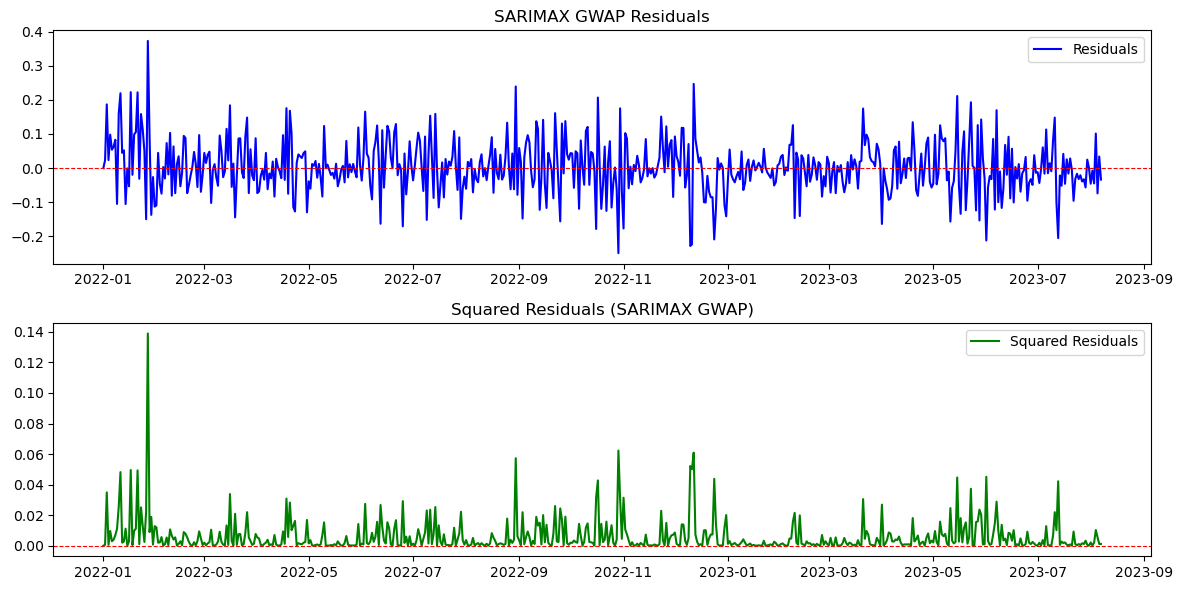

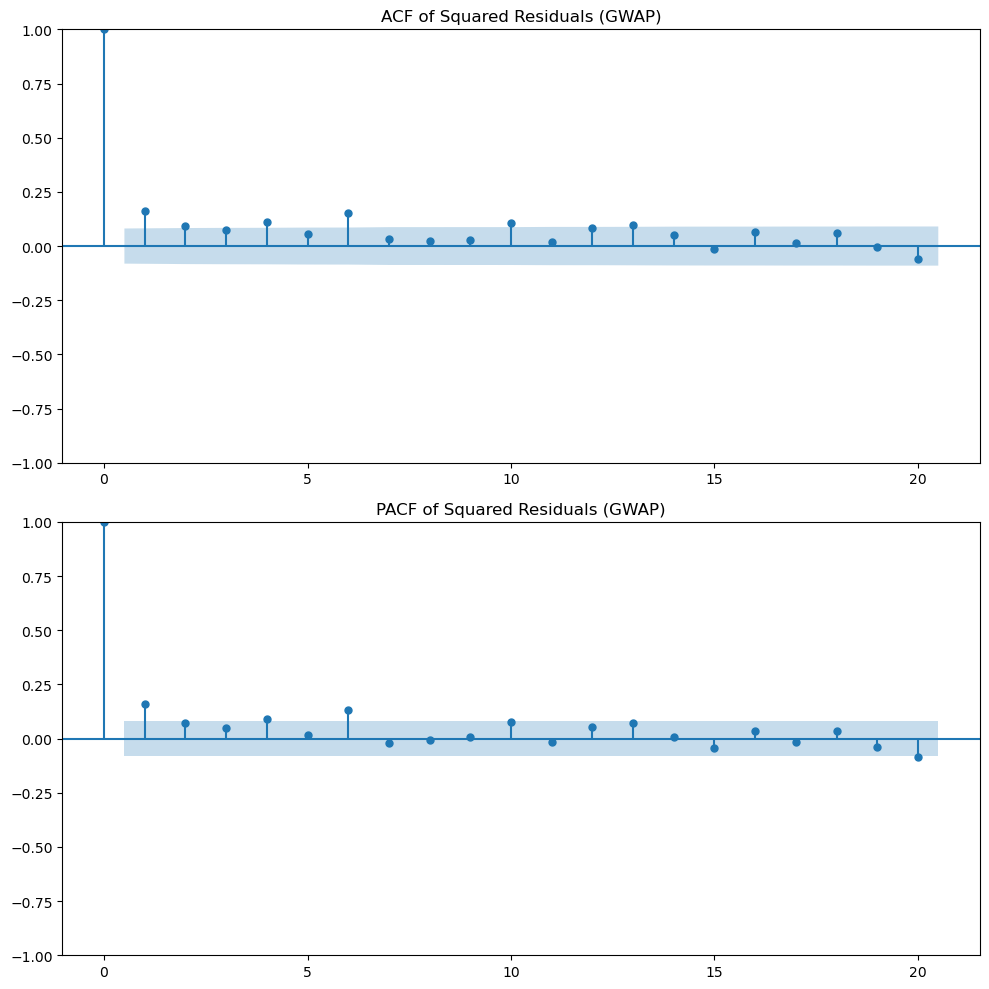

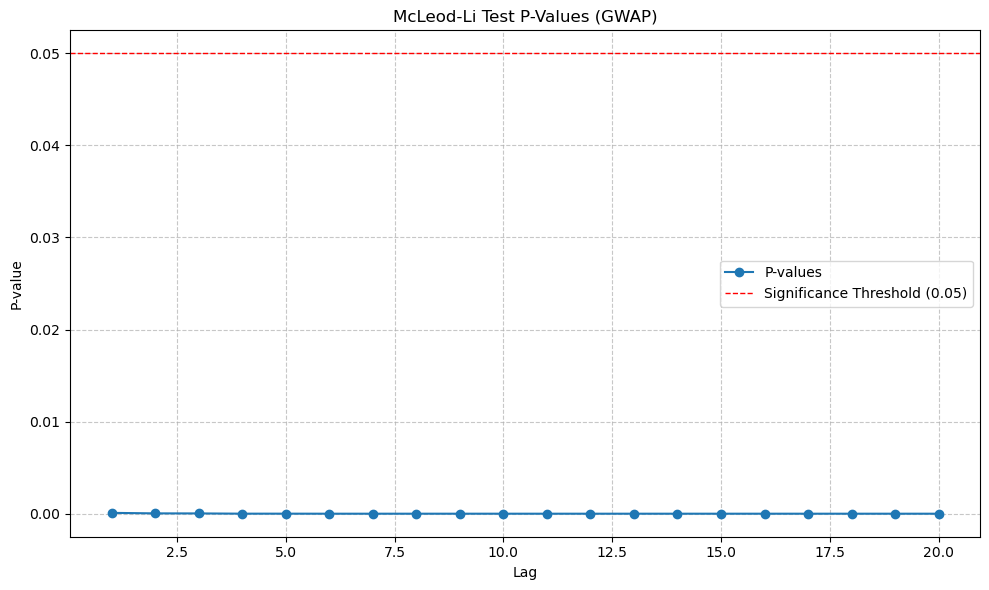

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,15.306865,9.138380e-05,15.215491,0.000096
1,2,20.498101,3.539109e-05,17.880946,0.000131
2,3,23.591210,3.040247e-05,19.997359,0.000170
3,4,30.878233,3.241570e-06,24.962253,0.000051
4,5,32.693690,4.328938e-06,25.098308,0.000133
5,6,46.531229,2.320393e-08,34.671393,0.000005
6,7,47.207780,5.084577e-08,34.926744,0.000012
7,8,47.580527,1.188184e-07,34.926823,0.000028
8,9,48.025028,2.526700e-07,34.707565,0.000067
9,10,54.687579,3.612039e-08,38.538185,0.000031


In [13]:
#Conducting residual analysis
%run GARCH.py

garch_testing(gwap_resid_train, 'GWAP', max_lag=20)

In [14]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1,4,6], 
    q_orders=[0,1,2,4,6,10,13], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with ged distribution: One of p or o must be strict

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_pval_2,beta_3,beta_4,beta_pval_3,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_8,beta_9,beta_10,beta_pval_7,beta_pval_8,beta_pval_9,beta_pval_10,beta_11,beta_12,beta_13,beta_pval_11,beta_pval_12,beta_pval_13,alpha_2,alpha_3,alpha_4,alpha_pval_2,alpha_pval_3,alpha_pval_4,alpha_5,alpha_6,alpha_pval_5,alpha_pval_6
0,1,1,GARCH,ged,-1379.789113,-1362.309509,693.894557,38.538185,0.000031,0.156090,0.000045,7.771467e-01,4.579777e-73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,GARCH,ged,-1378.477327,-1356.627822,694.238663,38.538185,0.000031,0.205596,0.000530,4.240330e-01,4.107544e-02,2.832903e-01,0.082318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,GARCH,t,-1377.465988,-1359.986384,692.732994,38.538185,0.000031,0.162024,0.000080,7.804888e-01,1.183857e-71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,GARCH,t,-1376.270283,-1354.420778,693.135141,38.538185,0.000031,0.215429,0.000607,4.192870e-01,3.775639e-02,2.914316e-01,0.068974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,GARCH,ged,-1376.040638,-1345.451332,695.020319,38.538185,0.000031,0.146549,0.026269,6.437395e-01,5.333353e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.011112,0.092481,1.000000,0.868566,0.197772,NaN,NaN,NaN,NaN
5,4,2,GARCH,ged,-1374.556577,-1339.597370,695.278289,38.538185,0.000031,0.185264,0.024386,3.571657e-01,7.330800e-01,2.370294e-01,0.772579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.013631,0.087287,1.000000,0.860523,0.144250,NaN,NaN,NaN,NaN
6,1,4,GARCH,ged,-1374.515514,-1343.926207,694.257757,38.538185,0.000031,0.231999,0.259298,3.239782e-01,6.336008e-01,2.418668e-01,0.596845,1.039844e-01,1.132125e-13,0.828822,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,6,0,GARCH,ged,-1374.232462,-1339.273254,695.116231,38.538185,0.000031,0.192039,0.012149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.924264e-02,0.080658,0.137349,0.138838,0.103635,0.010022,0.100731,8.013177e-02,0.126944,0.119861
8,4,1,GARCH,t,-1373.456066,-1342.866760,693.728033,38.538185,0.000031,0.150679,0.027547,6.656052e-01,4.934362e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.010755,0.086916,1.000000,0.876603,0.240193,NaN,NaN,NaN,NaN
9,1,4,GARCH,t,-1372.306542,-1341.717235,693.153271,38.538185,0.000031,0.240193,0.209996,3.320868e-01,5.789964e-01,2.530072e-01,0.493693,9.344461e-02,7.000963e-15,0.842915,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


GWAP GARCH

In [16]:
#Fitting GARCH model
%run GARCH.py

gwap_garch_fitted = fit_garch('GWAP', 'Garch', 1, 1, 'ged', '2023-8-8', gwap_resid_complete)

                             Zero Mean - GARCH Model Results                              
Dep. Variable:                gwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                  GARCH   Log-Likelihood:                693.895
Distribution:      Generalized Error Distribution   AIC:                          -1379.79
Method:                        Maximum Likelihood   BIC:                          -1362.31
                                                    No. Observations:                  584
Date:                            Sat, Mar 15 2025   Df Residuals:                      584
Time:                                    16:46:19   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
---------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




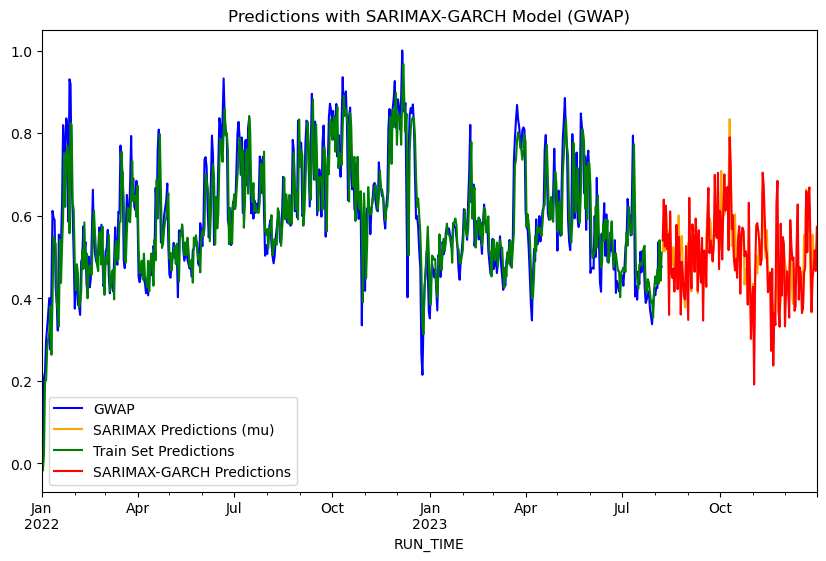

In [17]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

gwap_garch_predictions = garch_predict(
    'GWAP', 'ged', 'Garch', gwap_garch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

GWAP EGARCH

In [18]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1,4,6], 
    q_orders=[0,1,2,4,6,10,13], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with ged distribution: One of p or o mu

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_pval_2,beta_3,beta_4,beta_pval_3,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_8,beta_9,beta_10,beta_pval_7,beta_pval_8,beta_pval_9,beta_pval_10,beta_11,beta_12,beta_13,beta_pval_11,beta_pval_12,beta_pval_13,alpha_2,alpha_3,alpha_4,alpha_pval_2,alpha_pval_3,alpha_pval_4,alpha_5,alpha_6,alpha_pval_5,alpha_pval_6
0,1,1,EGARCH,ged,-1380.295565,-1362.815961,694.147783,38.538185,0.000031,0.302141,0.000003,9.038005e-01,4.343324e-142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,EGARCH,ged,-1379.776172,-1357.926668,694.888086,38.538185,0.000031,0.396995,0.000002,5.058005e-01,1.847627e-02,3.697006e-01,0.066773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,EGARCH,t,-1377.658942,-1360.179339,692.829471,38.538185,0.000031,0.308252,0.000006,9.096259e-01,2.002611e-145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,EGARCH,t,-1377.165977,-1355.316473,693.582989,38.538185,0.000031,0.402841,0.000003,5.185270e-01,2.096662e-02,3.666696e-01,0.085254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,EGARCH,ged,-1375.943977,-1345.354670,694.971989,38.538185,0.000031,0.391002,0.000033,9.020265e-01,2.352283e-138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.169681,0.073567,0.009796,0.157152,0.500491,0.906574,NaN,NaN,NaN,NaN
5,1,4,EGARCH,ged,-1375.776172,-1345.186866,694.888086,38.538185,0.000031,0.396995,0.000162,5.057866e-01,4.168655e-02,3.697106e-01,0.177505,0.000000e+00,3.893977e-16,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4,2,EGARCH,ged,-1373.943977,-1338.984769,694.971989,38.538185,0.000031,0.390997,0.000033,9.020247e-01,7.005663e-01,1.125117e-15,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.169619,0.073523,0.009821,0.854019,0.861513,0.962475,NaN,NaN,NaN,NaN
7,4,1,EGARCH,t,-1373.300593,-1342.711286,693.650297,38.538185,0.000031,0.397776,0.000048,9.107941e-01,1.021996e-151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.168889,0.067551,0.010521,0.171639,0.545694,0.902358,NaN,NaN,NaN,NaN
8,1,4,EGARCH,t,-1373.165978,-1342.576671,693.582989,38.538185,0.000031,0.402905,0.000182,5.185201e-01,3.112523e-02,3.666918e-01,0.220679,1.015734e-16,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,6,1,EGARCH,ged,-1371.966665,-1332.637556,694.983333,38.538185,0.000031,0.390000,0.000040,9.030225e-01,3.287107e-126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.168015,0.072727,0.002703,0.167960,0.508629,0.982128,0.019575,-0.014200,0.895709,0.916842


In [20]:
#Fitting EGARCH model
%run GARCH.py

gwap_egarch_fitted = fit_garch('GWAP', 'EGARCH', 1, 1, 'ged', '2023-8-8', gwap_resid_complete)

                             Zero Mean - EGARCH Model Results                             
Dep. Variable:                gwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                 EGARCH   Log-Likelihood:                694.148
Distribution:      Generalized Error Distribution   AIC:                          -1380.30
Method:                        Maximum Likelihood   BIC:                          -1362.82
                                                    No. Observations:                  584
Date:                            Sat, Mar 15 2025   Df Residuals:                      584
Time:                                    16:46:29   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
-----------------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006097. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




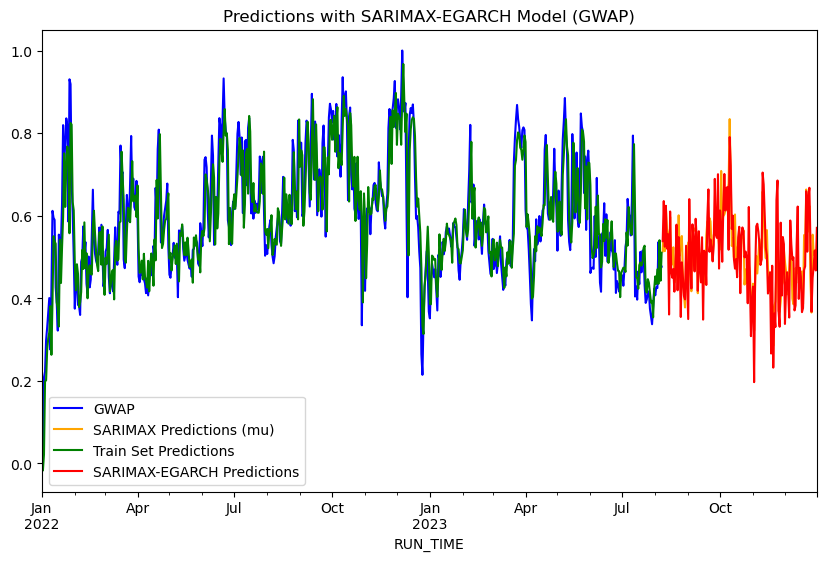

In [21]:
#Generate SARIMAX-EGARCH predictions
%run GARCH.py

gwap_egarch_predictions = garch_predict(
    'GWAP', 'ged', 'EGARCH', gwap_egarch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

LWAP Residual Analysis

In [22]:
#Generate residuals for LWAP

%run GARCH.py
lwap_resid_complete, lwap_resid_train = generate_resid(
    'LWAP',
    LWAP_train,
    LWAP_test,
    lwap_train_predict,
    lwap_test_predict,
    lwap_model_results
)

2022-01-01    0.000457
2022-01-02    0.018204
2022-01-03    0.185223
2022-01-04   -0.051962
2022-01-05    0.100346
2022-01-06    0.057488
2022-01-07    0.057483
2022-01-08    0.088338
2022-01-09   -0.109368
2022-01-10    0.165369
2022-01-11    0.237502
2022-01-12    0.044806
2022-01-13    0.054049
2022-01-14   -0.125334
2022-01-15   -0.010727
2022-01-16   -0.069142
2022-01-17    0.248989
2022-01-18   -0.011658
2022-01-19    0.101525
2022-01-20    0.111949
2022-01-21    0.235627
2022-01-22   -0.031860
2022-01-23    0.169519
2022-01-24    0.120153
2022-01-25    0.051838
2022-01-26   -0.159241
2022-01-27    0.391529
2022-01-28    0.104270
2022-01-29   -0.131538
2022-01-30   -0.015835
2022-01-31   -0.131982
2022-02-01   -0.134001
2022-02-02    0.055105
2022-02-03   -0.056345
2022-02-04   -0.095880
2022-02-05   -0.003033
2022-02-06   -0.041384
2022-02-07    0.085470
2022-02-08   -0.028641
2022-02-09    0.114408
2022-02-10   -0.094330
2022-02-11    0.071496
2022-02-12   -0.090183
2022-02-13 

RUN_TIME
2022-01-01    0.000457
2022-01-02    0.018204
2022-01-03    0.185223
2022-01-04   -0.051962
2022-01-05    0.100346
2022-01-06    0.057488
2022-01-07    0.057483
2022-01-08    0.088338
2022-01-09   -0.109368
2022-01-10    0.165369
2022-01-11    0.237502
2022-01-12    0.044806
2022-01-13    0.054049
2022-01-14   -0.125334
2022-01-15   -0.010727
2022-01-16   -0.069142
2022-01-17    0.248989
2022-01-18   -0.011658
2022-01-19    0.101525
2022-01-20    0.111949
2022-01-21    0.235627
2022-01-22   -0.031860
2022-01-23    0.169519
2022-01-24    0.120153
2022-01-25    0.051838
2022-01-26   -0.159241
2022-01-27    0.391529
2022-01-28    0.104270
2022-01-29   -0.131538
2022-01-30   -0.015835
2022-01-31   -0.131982
2022-02-01   -0.134001
2022-02-02    0.055105
2022-02-03   -0.056345
2022-02-04   -0.095880
2022-02-05   -0.003033
2022-02-06   -0.041384
2022-02-07    0.085470
2022-02-08   -0.028641
2022-02-09    0.114408
2022-02-10   -0.094330
2022-02-11    0.071496
2022-02-12   -0.090183
20

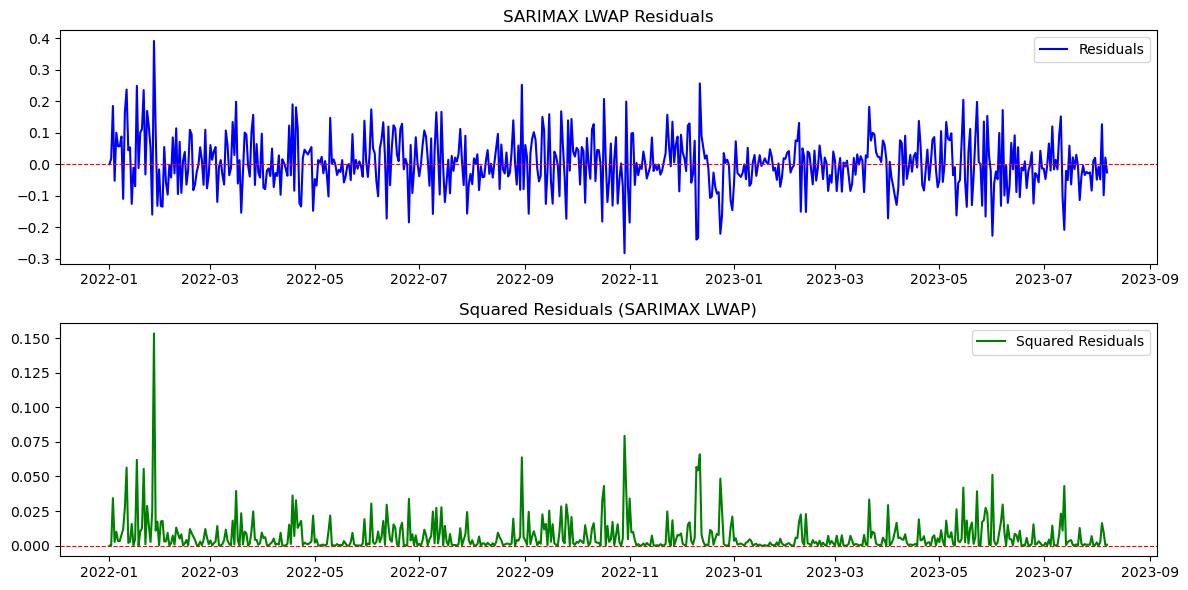

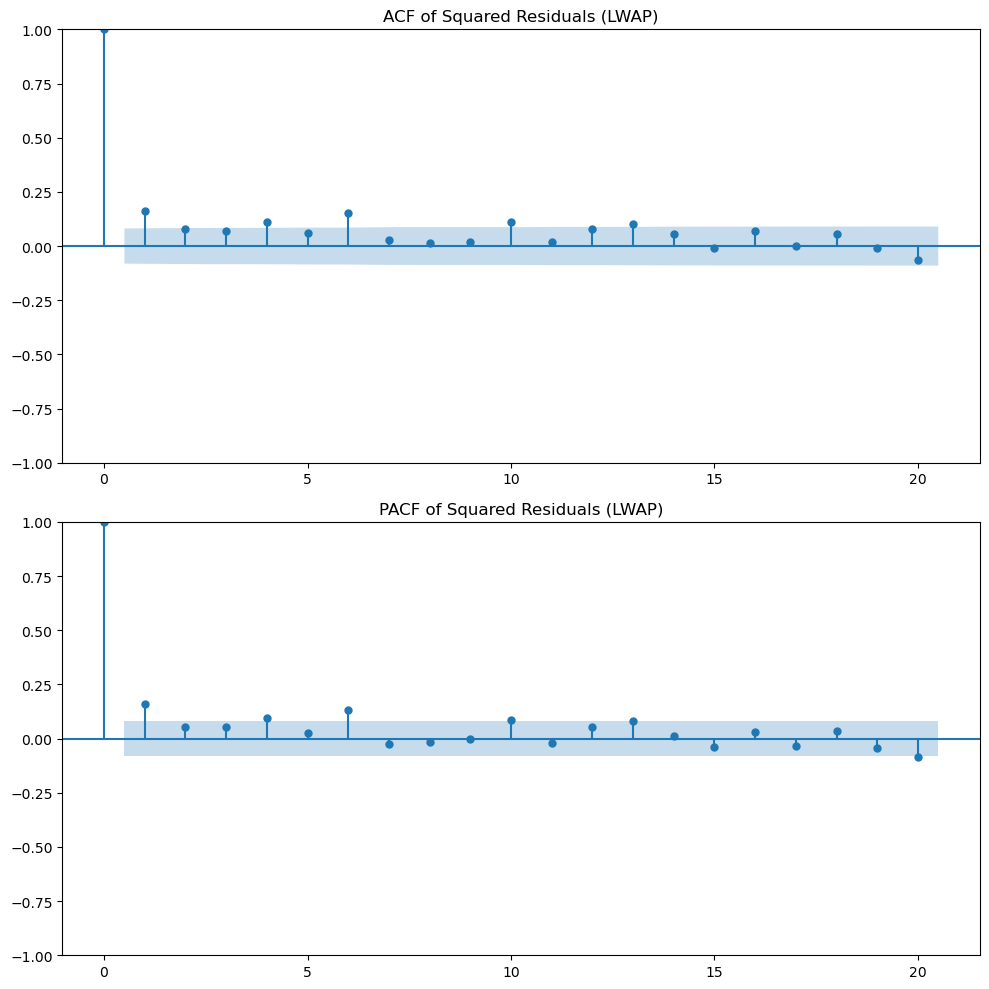

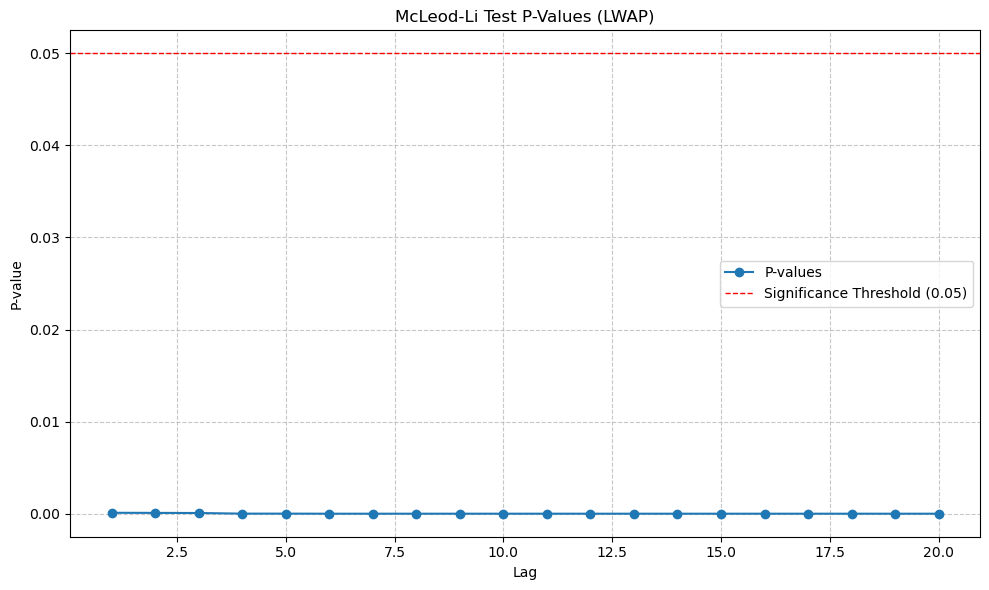

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,15.128575,1.004316e-04,15.040419,0.000105
1,2,18.662873,8.859487e-05,16.542673,0.000256
2,3,21.683106,7.592277e-05,18.731052,0.000311
3,4,29.171761,7.213797e-06,23.847132,0.000086
4,5,31.381995,7.873126e-06,24.165832,0.000202
5,6,45.381283,3.930758e-08,33.951040,0.000007
6,7,45.874948,9.245689e-08,34.360900,0.000015
7,8,45.989747,2.387685e-07,34.436708,0.000034
8,9,46.208715,5.507962e-07,34.233978,0.000081
9,10,53.651051,5.635126e-08,38.713568,0.000028


In [23]:
#Conducting residual analysis
%run GARCH.py

garch_testing(lwap_resid_train, 'LWAP', max_lag=20)

In [24]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1,4,6], 
    q_orders=[0,1,2,4,6,10,13], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,2) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with ged distribution: One of p or o must be strict

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_pval_2,beta_3,beta_4,beta_pval_3,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_8,beta_9,beta_10,beta_pval_7,beta_pval_8,beta_pval_9,beta_pval_10,beta_11,beta_12,beta_13,beta_pval_11,beta_pval_12,beta_pval_13,alpha_2,alpha_3,alpha_4,alpha_pval_2,alpha_pval_3,alpha_pval_4,alpha_5,alpha_6,alpha_pval_5,alpha_pval_6
0,1,1,GARCH,ged,-1283.022753,-1265.543149,645.511377,38.713568,0.000028,0.144639,0.000177,7.796021e-01,2.932483e-62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,GARCH,ged,-1281.895563,-1260.046058,645.947781,38.713568,0.000028,0.195746,0.000761,3.859464e-01,4.948812e-02,3.167036e-01,0.042795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,GARCH,t,-1279.766547,-1262.286943,643.883273,38.713568,0.000028,0.144708,0.000292,7.818980e-01,7.206240e-61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,GARCH,ged,-1278.981472,-1248.392165,646.490736,38.713568,0.000028,0.136084,0.041595,6.348161e-01,1.455999e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.261547e-14,0.020520,0.082391,1.000000,0.763415,0.252840,NaN,NaN,NaN,NaN
4,1,2,GARCH,t,-1278.677210,-1256.827705,644.338605,38.713568,0.000028,0.196355,0.001043,3.852309e-01,5.619892e-02,3.208916e-01,0.047756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,0,GARCH,ged,-1277.961964,-1243.002756,646.980982,38.713568,0.000028,0.177203,0.018617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.583411e-02,0.079452,0.121693,0.261815,0.103145,0.014697,0.096740,0.079871,0.123830,0.135716
6,1,4,GARCH,ged,-1277.958578,-1247.369271,645.979289,38.713568,0.000028,0.219843,0.119128,2.834577e-01,5.845600e-01,2.731568e-01,0.475649,1.084652e-01,8.924532e-15,0.767002,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4,2,GARCH,ged,-1277.712828,-1242.753620,646.856414,38.713568,0.000028,0.179133,0.021300,2.910099e-01,7.771679e-01,2.899287e-01,0.718459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.018487,0.078500,1.000000,0.828514,0.143740,NaN,NaN,NaN,NaN
8,6,1,GARCH,ged,-1275.961964,-1236.632855,646.980982,38.713568,0.000028,0.177183,0.024843,0.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.584147e-02,0.079447,0.121692,0.675595,0.155940,0.046092,0.096743,0.079870,0.254196,0.326540
9,4,1,GARCH,t,-1275.651304,-1245.061997,644.825652,38.713568,0.000028,0.134927,0.045985,6.469841e-01,9.446431e-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.020275,0.079314,1.000000,0.767614,0.283654,NaN,NaN,NaN,NaN


In [26]:
#Fitting GARCH model
%run GARCH.py

lwap_garch_fitted = fit_garch('LWAP', 'Garch', 1, 1, 'ged', '2023-8-8', lwap_resid_complete)

                             Zero Mean - GARCH Model Results                              
Dep. Variable:                lwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                  GARCH   Log-Likelihood:                645.511
Distribution:      Generalized Error Distribution   AIC:                          -1283.02
Method:                        Maximum Likelihood   BIC:                          -1265.54
                                                    No. Observations:                  584
Date:                            Sat, Mar 15 2025   Df Residuals:                      584
Time:                                    16:46:41   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
---------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




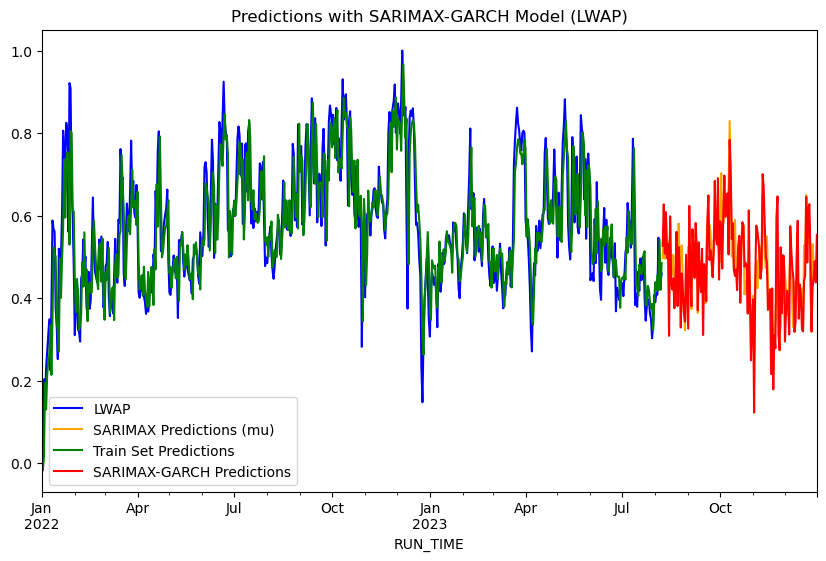

In [27]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_garch_predictions = garch_predict(
    'LWAP', 'ged', 'Garch', lwap_garch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

LWAP EGARCH

In [28]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1,4,6], 
    q_orders=[0,1,2,4,6,10,13], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,2) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with ged distribution: One of p or o mu

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_pval_2,beta_3,beta_4,beta_pval_3,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_8,beta_9,beta_10,beta_pval_7,beta_pval_8,beta_pval_9,beta_pval_10,beta_11,beta_12,beta_13,beta_pval_11,beta_pval_12,beta_pval_13,alpha_2,alpha_3,alpha_4,alpha_pval_2,alpha_pval_3,alpha_pval_4,alpha_5,alpha_6,alpha_pval_5,alpha_pval_6
0,1,1,EGARCH,ged,-1283.554000,-1266.074396,645.777000,38.713568,0.000028,0.281875,0.000016,8.988713e-01,3.623426e-122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,EGARCH,ged,-1283.209202,-1261.359697,646.604601,38.713568,0.000028,0.376957,0.000004,4.699226e-01,1.797300e-02,3.964384e-01,0.032847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,EGARCH,t,-1280.209536,-1262.729933,644.104768,38.713568,0.000028,0.280612,0.000028,9.012344e-01,1.504176e-120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,EGARCH,t,-1279.836107,-1257.986602,644.918054,38.713568,0.000028,0.373684,0.000008,4.774734e-01,2.575108e-02,3.935150e-01,0.050457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,EGARCH,ged,-1279.500374,-1248.911067,646.750187,38.713568,0.000028,0.370509,0.000080,8.932837e-01,1.253551e-108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.179454,0.085322,0.015268,0.130571,0.435504,0.850052,NaN,NaN,NaN,NaN
5,1,4,EGARCH,ged,-1279.210169,-1248.620862,646.605084,38.713568,0.000028,0.378913,0.000503,4.656949e-01,7.592144e-02,3.909552e-01,0.148574,8.915070e-03,0.000000e+00,0.980410,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4,2,EGARCH,ged,-1277.500374,-1242.541166,646.750187,38.713568,0.000028,0.370547,0.000081,8.932783e-01,8.366941e-01,2.901973e-16,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.179523,0.085405,0.015246,0.910432,0.908689,0.968995,NaN,NaN,NaN,NaN
7,4,1,EGARCH,t,-1276.123614,-1245.534307,645.061807,38.713568,0.000028,0.366983,0.000134,8.975004e-01,6.529006e-111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.175191,0.079529,0.017989,0.148478,0.474853,0.826642,NaN,NaN,NaN,NaN
8,1,4,EGARCH,t,-1275.836111,-1245.246805,644.918056,38.713568,0.000028,0.373842,0.000905,4.773212e-01,6.474954e-02,3.929504e-01,0.183923,6.800839e-04,1.932100e-16,0.998631,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,6,1,EGARCH,ged,-1275.599056,-1236.269947,646.799528,38.713568,0.000028,0.369566,0.000108,9.000406e-01,2.977922e-109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.179788,0.087615,0.010591,0.141891,0.431556,0.927350,0.026851,-0.038554,0.846471,0.773714


In [30]:
#Fitting EGARCH model
%run GARCH.py

lwap_egarch_fitted = fit_garch('LWAP', 'EGARCH', 1, 1, 'ged', '2023-8-8', lwap_resid_complete)

                             Zero Mean - EGARCH Model Results                             
Dep. Variable:                lwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                 EGARCH   Log-Likelihood:                645.777
Distribution:      Generalized Error Distribution   AIC:                          -1283.55
Method:                        Maximum Likelihood   BIC:                          -1266.07
                                                    No. Observations:                  584
Date:                            Sat, Mar 15 2025   Df Residuals:                      584
Time:                                    16:46:50   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
-----------------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007041. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




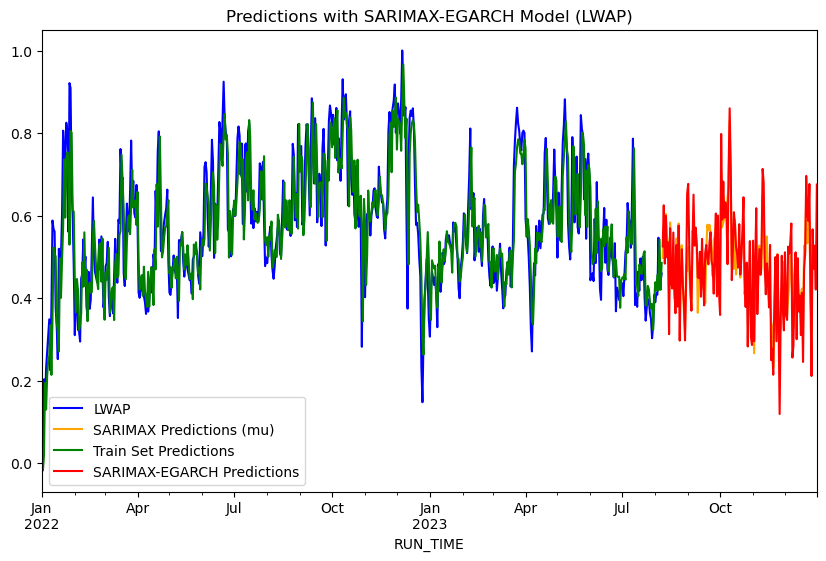

In [31]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_egarch_predictions = garch_predict(
    'LWAP', 'ged', 'EGARCH', lwap_egarch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

Applying inverse transformations

In [32]:
def prep_predictions(gwap_predictions, lwap_predictions):
    gwap_predictions_df = gwap_predictions.to_frame(name='GWAP')
    lwap_predictions_df = lwap_predictions.to_frame(name='LWAP')

    %run transformscript.py

    inverse_gwap_predictions = inverse_transform_data(gwap_predictions_df, 'SARIMAX', 'LUZ', 'GWAP')
    inverse_lwap_predictions = inverse_transform_data(lwap_predictions_df, 'SARIMAX', 'LUZ', 'LWAP')

    return inverse_gwap_predictions, inverse_lwap_predictions

In [33]:
#Preparing the predictions of the various time series models
inverse_gwap_sarimax_predictions, inverse_lwap_sarimax_predictions = prep_predictions(gwap_test_predict, lwap_test_predict)
inverse_gwap_garch_predictions, inverse_lwap_garch_predictions = prep_predictions(gwap_garch_predictions, lwap_garch_predictions)
inverse_gwap_egarch_predictions, inverse_lwap_egarch_predictions = prep_predictions(gwap_egarch_predictions, lwap_egarch_predictions)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator PowerTransformer from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator MinMaxScaler from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator Pipeline from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at

Mean Absolute Error (MAE) on Test Set for GWAP: 1396.9989658218942
Root Mean Squared Error (RMSE) on Test Set for GWAP: 2196.2132474865657
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 21.824922933469963


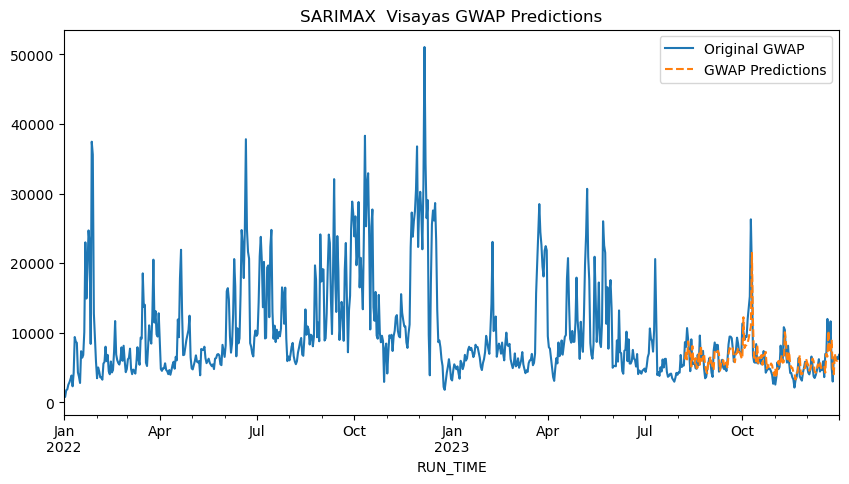

Mean Absolute Error (MAE) on Test Set for LWAP: 1565.8593660262677
Root Mean Squared Error (RMSE) on Test Set for LWAP: 2402.1857009096357
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 21.570889886064705


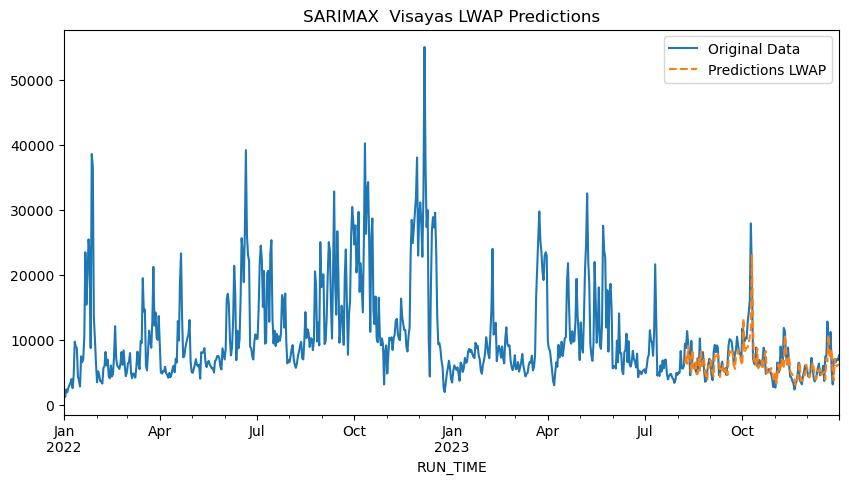

In [34]:
#Assessing SARIMAX model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_vis_gwap, complete_vis_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_sarimax_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_sarimax_predictions, Region = 'Visayas', Volatility = '')

Mean Absolute Error (MAE) on Test Set for GWAP: 1892.219249265017
Root Mean Squared Error (RMSE) on Test Set for GWAP: 2830.248951398193
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 31.013817074685747


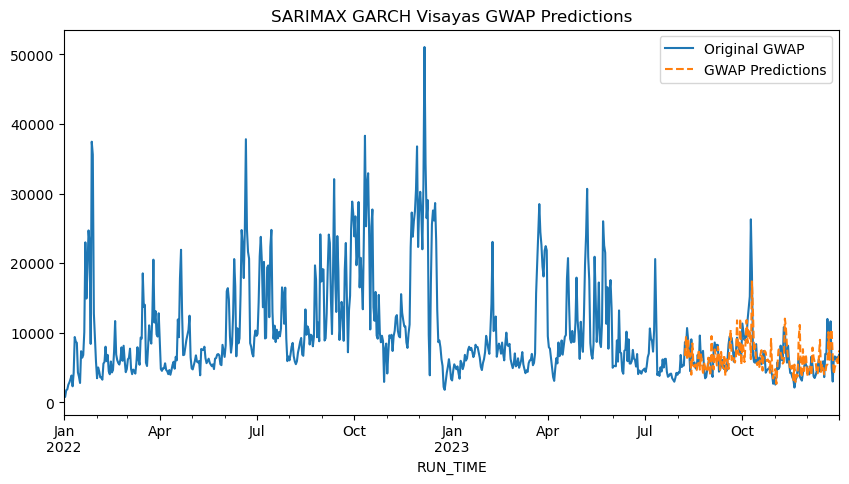

Mean Absolute Error (MAE) on Test Set for LWAP: 2022.2405735793784
Root Mean Squared Error (RMSE) on Test Set for LWAP: 3011.7966733255153
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 29.551490068493564


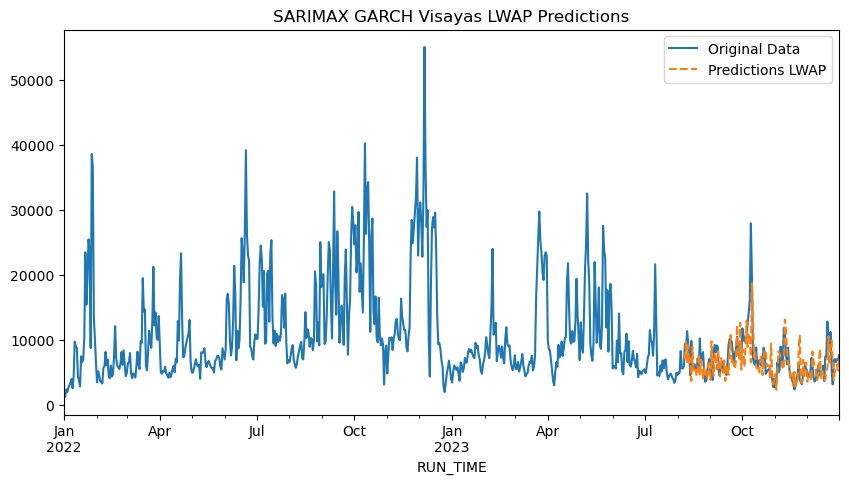

In [35]:
#Assessing SARIMAX-GARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_vis_gwap, complete_vis_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_garch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_garch_predictions, Region = 'Visayas', Volatility = 'GARCH')

Mean Absolute Error (MAE) on Test Set for GWAP: 1880.6087745351324
Root Mean Squared Error (RMSE) on Test Set for GWAP: 2820.029072300917
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 30.84474498487712


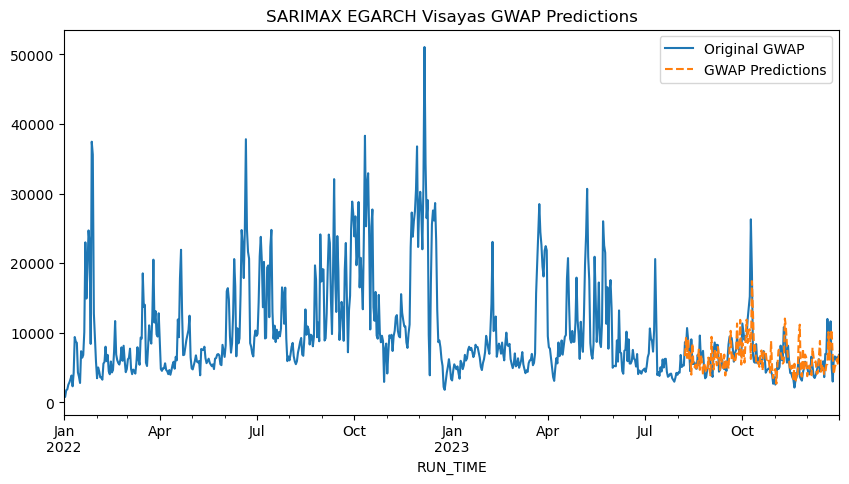

Mean Absolute Error (MAE) on Test Set for LWAP: 2168.6307626563666
Root Mean Squared Error (RMSE) on Test Set for LWAP: 3058.745457112658
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 30.752859830288624


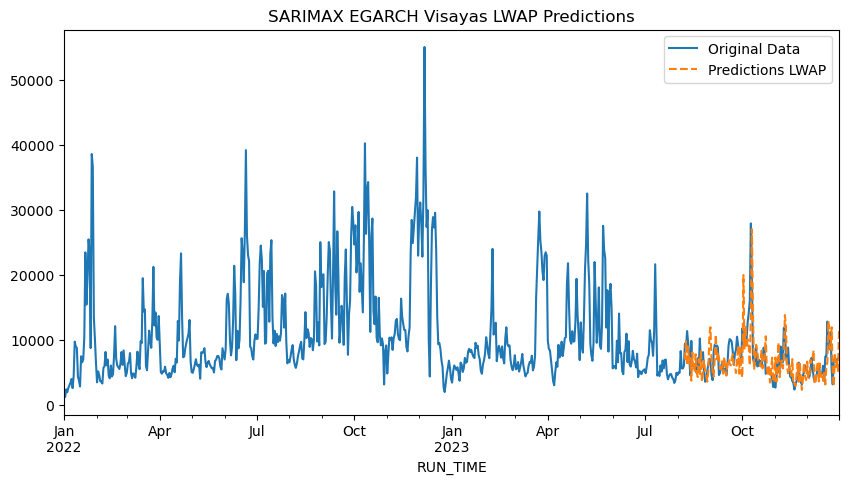

In [36]:
#Assessing SARIMAX-GARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_vis_gwap, complete_vis_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_egarch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_egarch_predictions, Region = 'Visayas', Volatility = 'EGARCH')